# The SAV model, in Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/sav-osemosys-trd-2019/blob/main/notebooks/01_model.ipynb)

The model behind **Jones and Leibowicz (2019)**, *Transportation Research Part D* —
an OSeMOSYS energy–transportation model of Austin, Texas, written here in `gurobipy`
and reading plain CSVs.

**Why this notebook exists.** The original is GAMS, which is licensed for everyone
including academics. Until this port, reading the formulation at all required commercial
software — not solving it, *reading* it. Everything below can be read by anyone, and the
solve at the end runs on **HiGHS**, which is `pip install highspy` and needs no licence.

The sections follow the model's structure, and each is a section of the package:

| notebook section | module |
|---|---|
| sets and sparsity | `sav_osemosys.sets` |
| parameters and scenario levers | `sav_osemosys.parameters` |
| decision variables | `sav_osemosys.variables` |
| constraints | `sav_osemosys.constraints` |
| objective | `sav_osemosys.objective` |

The notebook narrates; the package implements. They are compared at the end rather than
being allowed to drift.

In [1]:
try:
    import sav_osemosys  # noqa: F401
except ImportError:
    !pip install -q "git+https://github.com/sear-labs/sav-osemosys-trd-2019.git" highspy

import matplotlib.pyplot as plt
import pandas as pd

RAW_BASE = "https://raw.githubusercontent.com/sear-labs/sav-osemosys-trd-2019/main"
plt.rcParams["figure.dpi"] = 110

## 0. Solvers and licences — what runs without one

**Most of this notebook needs no licence.** The model is built and solved below with
**HiGHS**, which is open source, pip-installable and has no size limit.

Gurobi is optional and only used if you have a licence. Two things worth knowing, both
measured rather than assumed:

| | what it is | works here? |
|---|---|---|
| **Gurobi pip licence** | bundled, size-limited | **No** — caps at 2,000 variables; the smallest useful version of this model is 4,726 |
| **Named-User Academic** | a `gurobi.lic` file | Locally yes; **not in Colab** — node-locked, and the VM differs every session |
| **WLS Academic** | three values over the network | **Yes** — the one that works in Colab |
| **HiGHS** | `pip install highspy` | **Yes, always** |

Credentials go in Colab secrets, never in the notebook. `SecretNotFoundError` on first
run is expected if you have not set them.

In [2]:
import os

import highspy

KEYS = ("WLSACCESSID", "WLSSECRET", "LICENSEID")
found = {k: os.environ.get("GRB_" + k) for k in KEYS}
if not all(found.values()):
    try:
        from google.colab import userdata
        found = {k: userdata.get("GRB_" + k) for k in KEYS}
    except Exception:
        found = {}

GUROBI_ENV = None
HAVE_GUROBI = False
try:
    import gurobipy as gp
    if found and all(found.values()):
        GUROBI_ENV = gp.Env(params={"WLSACCESSID": found["WLSACCESSID"],
                                    "WLSSECRET": found["WLSSECRET"],
                                    # userdata.get returns a string; LICENSEID is an int
                                    "LICENSEID": int(found["LICENSEID"])})
    with gp.Model(env=GUROBI_ENV) if GUROBI_ENV else gp.Model() as _probe:
        _probe.addVars(3000)          # past the 2,000-variable pip cap
        _probe.update()
    HAVE_GUROBI = True
except Exception as exc:
    print(f"Gurobi unavailable ({type(exc).__name__}) — HiGHS will be used throughout.")

print(f"HiGHS       : available ({highspy.Highs().version()})")
print(f"Gurobi      : {'available' if HAVE_GUROBI else 'not available — everything below still runs'}")

Set parameter Username


Set parameter LicenseID to value 2750151


Academic license - for non-commercial use only - expires 2026-12-04


HiGHS       : available (1.15.1)
Gurobi      : available


## 1. Sets

The model's index sets, read straight from `data/instance/` — 102 CSVs exported from the
GAMS data file so the instance is readable without GAMS.

Data is loaded **local first, then from GitHub**, so this cell works from a clone and
from a Colab session with nothing checked out.

In [3]:
from sav_osemosys import Instance
from sav_osemosys.sets import build_indices

inst = Instance()
print("instance source:", inst.source)

ix = build_indices(inst)
print()
print(ix.summary())

instance source: C:\Users\jonesec\dev\repo\projects\sav-osemosys-trd-2019\data\instance

36 years x 72 timeslices x 51 technologies x 15 fuels
  producing (t,f) pairs: 51 of 765 dense (6.7%)
  consuming (t,f) pairs: 44 of 765 dense (5.8%)


### The sparsity that makes this tractable in Python

GAMS generates a variable for every technology–fuel pair — including *(coal plant,
gasoline)*. Only **51 of 765 pairs actually produce** anything and 44 consume.

That is why the GAMS model reports 18.8M variables and this one builds 1.56M for the
*same mathematics*. Nothing is approximated: a variable that exists only to be forced to
zero is padding, and any solver's presolve removes it anyway. This declines to create it.

In [4]:
dense = len(ix.technologies) * len(ix.fuels)
print(f"technologies x fuels        {dense:>6}")
print(f"  pairs that produce        {len(ix.produces_tf):>6}  ({len(ix.produces_tf)/dense:.1%})")
print(f"  pairs that consume        {len(ix.consumes_tf):>6}  ({len(ix.consumes_tf)/dense:.1%})")
print()
print("day / night split, which the charging lever uses:")
print(f"  LowV2G  (hours 6-20)      {len(ix.low_v2g):>6} timeslices")
print(f"  HighV2G (hours 21-5)      {len(ix.high_v2g):>6} timeslices")

technologies x fuels           765
  pairs that produce            51  (6.7%)
  pairs that consume            44  (5.8%)

day / night split, which the charging lever uses:
  LowV2G  (hours 6-20)          45 timeslices
  HighV2G (hours 21-5)          27 timeslices


## 2. Parameters, and the four scenario levers

Table 2 of the paper crosses four things: SAV diffusion, carbon tax, charging paradigm,
and a travel-demand multiplier. A `Scenario` is one row of that table.

The tax is the paper's own: **$20/tCO₂ in the base year, rising 5% a year**. It is
already present in the GAMS data file — built, and then zeroed on the very next line.

In [5]:
from sav_osemosys.parameters import Parameters, Scenario

central = Scenario(3, sav="70", tax="no", charging="optimized", dm=1)
taxed   = Scenario(8, sav="70", tax="yes", charging="optimized", dm=1)

for s in (central, taxed):
    p = Parameters(inst, ix, s)
    a = p.applied()
    print(s.label())
    print(f"    carbon price 2015 / 2050   {a['tax_first_year']:>10,.2f} / {a['tax_last_year']:>10,.2f}")
    print(f"    VMT / FMT in 2050          {a['vmt_last_year']:>10,.1f} / {a['fmt_last_year']:>10,.1f}")
    print(f"    charge factor day / night  {a['charge_factor_day']:>10.3f} / {a['charge_factor_night']:>10.3f}")
    print()

scenario 3: sav=70, tax=no, charging=optimized, dm=1
    carbon price 2015 / 2050         0.00 /       0.00
    VMT / FMT in 2050             4,259.7 /    9,707.8
    charge factor day / night       0.598 /      0.977



scenario 8: sav=70, tax=yes, charging=optimized, dm=1
    carbon price 2015 / 2050        20.00 /     110.32
    VMT / FMT in 2050             4,259.7 /    9,707.8
    charge factor day / night       0.598 /      0.977



### The check the whole scenario grid rests on

The SAV cases split one travel demand into private VMT and fleet FMT; the no-SAV case is
that same demand undivided. If that reading is right, **VMT + FMT must equal the no-SAV
row in every year** — and it does, to 2e-4.

This is asserted rather than assumed because ten scenarios built on a wrong split would
all solve and all report success.

In [6]:
p = Parameters(inst, ix, central)
print(f"demand-split agreement gap: {p.demand_agreement_gap:.2e}   (tolerance 1e-3)")

share = p.base_fmt["2050"] / (p.base_vmt["2050"] + p.base_fmt["2050"])
print(f"SAV share of travel demand in 2050: {share:.1%}   (the paper's '70% by 2050')")

demand-split agreement gap: 2.03e-04   (tolerance 1e-3)
SAV share of travel demand in 2050: 69.5%   (the paper's '70% by 2050')


## 3. Decision variables

Named as OSeMOSYS names them, so this and `osemosys_equations.gms` can be read side by
side. All are non-negative except the objective and the two cost differences.

The definitional variables — rates, annual totals, cost components — are kept rather than
substituted out. They are what makes the formulation legible against the published model,
and presolve eliminates them at no cost to the answer.

In [7]:
from sav_osemosys.model import build

REDUCED_YEARS = [str(y) for y in range(2015, 2021)]
REDUCED_SLICES = [f"{p_}{h}" for p_ in ("W", "SF", "S") for h in (1, 5, 9, 13, 17, 21)]

m3 = build(inst, central, years=REDUCED_YEARS, timeslices=REDUCED_SLICES,
           env=GUROBI_ENV) if HAVE_GUROBI else None

if m3 is not None:
    counts = {name: len(v) if hasattr(v, "__len__") else 1 for name, v in m3.var.items()}
    top = sorted(counts.items(), key=lambda kv: -kv[1])[:12]
    print(f"{'variable':<42}{'count':>10}")
    for name, n in top:
        print(f"{name:<42}{n:>10,}")
    print(f"\n{m3.size()}")
else:
    print("Gurobi not available — the model is built from the shipped .mps below instead.")

variable                                       count
RateOfActivity                                11,016
RateOfTotalActivity                            5,508
RateOfProductionByTechnologyByMode             5,508
RateOfProductionByTechnology                   5,508
ProductionByTechnology                         5,508
DemandResponseLevel                            4,860
RateOfUseByTechnologyByMode                    4,752
RateOfUseByTechnology                          4,752
UseByTechnology                                4,752
RateOfProduction                               1,620
RateOfUse                                      1,620
RateOfDemand                                   1,620

70,355 variables, 72,877 constraints, 187,411 nonzeros


## 4. Constraints

107 equation blocks, grouped in `sav_osemosys.constraints` exactly as the GAMS file
groups them: demand, storage, capacity adequacy, energy balance, accounting, capital and
salvage, operating costs, capacity limits, activity limits, reserve margin, renewable
target, emissions, the study's own additions, and demand response.

Two are worth reading closely, because both are easy to get wrong:

In [8]:
import inspect
from sav_osemosys import constraints

# The demand constraint, which is where the scenario levers enter the model.
print(inspect.getsource(constraints._demand))

def _demand(b: "BuiltModel") -> None:
    import gurobipy as gp
    m, ix, p, v = b.model, b.indices, b.parameters, b.var
    D = p.dr_types
    m.addConstrs(
        ((p.annual_demand[(f, y)] * p.demand_profile[(f, l, y)]
          - gp.quicksum(p.dr_tag[(f, d)] * v["DemandResponseLevel"][y, d, f, l] for d in D))
         / p.year_split[(l, y)] == v["RateOfDemand"][y, l, f]
         for y in ix.years for l in ix.timeslices for f in ix.fuels),
        name="EQ_SpecifiedDemand1")



**The storage level recursion uses a *circular* lag.** GAMS writes
`StorageLevel(s, y, L--1, r)`, so the first slice of a season follows the *last* one —
the day closes on itself, and a separate constraint forces the round trip to net to zero.
Implementing that as a plain lag would leave the first hour unconstrained.

**And the model carries one variable *bound*, not an equation:**

```gams
ProductionByTechnology.fx(y, LowV2G, "EV_CHARGE", f, r) = 0;
```

Private EV charging is fixed to zero in every daytime slice — always, in every scenario.
It sits among the variable declarations, so porting the equations one at a time misses it
entirely. Omitting it left this port's objective 1.70 low on 72,412: too small to notice,
far too large to be arithmetic.

## 5. Objective

One equation in GAMS. Presented in three parts here because at this scale a single
summation over millions of terms tells a reader nothing about what the number is made of
— a decision about *this* model's size, not a general rule.

In [9]:
from sav_osemosys.objective import add_objective
print(inspect.getsource(add_objective))

def add_objective(b: "BuiltModel") -> None:
    import gurobipy as gp

    m, ix, v = b.model, b.indices, b.var

    # Part 1: technology cost - capital, operating and emissions penalty, less salvage.
    technology_cost = gp.quicksum(
        v["TotalDiscountedCost"][y, t] for y in ix.years for t in ix.technologies)

    # Part 2: storage - capital less salvage. Storage carries no operating cost here.
    storage_cost = gp.quicksum(
        v["TotalDiscountedStorageCost"][y, s] for y in ix.years for s in ix.storages)

    # Part 3: demand response, paid for shifting load out of a timeslice.
    demand_response_cost = gp.quicksum(
        v["DiscountedDemandResponseAnnualCost"][y] for y in ix.years)

    m.addConstr(v["z"] == technology_cost + storage_cost + demand_response_cost, name="cost")
    m.setObjective(v["z"], gp.GRB.MINIMIZE)



## 6. Build and solve — with HiGHS, no licence

The full model is 36 years × 72 timeslices and 1.56M variables. The reduced instance
below keeps every technology, both charging paradigms and full storage cycling, but uses
**6 years × 18 timeslices** — small enough to solve in a second in a free Colab session.

The reduction is a *set restriction*, not a different model: the same formulation code
builds both, which is what makes the small one evidence about the large one.

In [10]:
import gzip, shutil, tempfile, time, urllib.request
from pathlib import Path

def fetch(relative):
    local = next((q for q in [Path.cwd(), *Path.cwd().parents]
                  if (q / relative).is_file()), None)
    if local:
        return local / relative
    target = Path(tempfile.gettempdir()) / Path(relative).name
    if not target.exists():
        urllib.request.urlretrieve(f"{RAW_BASE}/{relative}", target)
    return target

mps_gz = fetch("artifacts/reduced-scenario-03.mps.gz")
mps = Path(tempfile.mkdtemp()) / "reduced.mps"
with gzip.open(mps_gz, "rb") as f, mps.open("wb") as o:
    shutil.copyfileobj(f, o)

h = highspy.Highs()
h.setOptionValue("output_flag", False)
h.readModel(str(mps))
started = time.time()
h.run()
elapsed = time.time() - started

info = h.getInfo()
print(f"HiGHS status     {h.modelStatusToString(h.getModelStatus())}")
print(f"objective        {info.objective_function_value:,.6f}")
print(f"solve time       {elapsed:.1f}s")

HiGHS status     Optimal
objective        5,900.422796
solve time       0.5s


In [11]:
if HAVE_GUROBI and m3 is not None:
    m3.model.Params.OutputFlag = 0
    m3.model.optimize()
    g = m3.model.ObjVal
    hi = info.objective_function_value
    print(f"gurobipy   {g:,.6f}")
    print(f"HiGHS      {hi:,.6f}")
    print(f"relative   {abs(g-hi)/abs(g):.2e}   <- two independent solvers, same answer")
else:
    print("Gurobi not available; the HiGHS answer above stands on its own.")

gurobipy   5,900.422797
HiGHS      5,900.422796
relative   8.39e-11   <- two independent solvers, same answer


## 7. The reduced run against the published one

**This is the figure to spend time on.** The reduced instance is plotted against the
published result, so the reduction's limits are visible rather than hidden — and so that
a reader who changes a parameter above can see what their change did relative to the
original.

A 6-year model cannot reproduce a 2050 trajectory and is not trying to. The claim here is
*this formulation solves and behaves*; the reproduction claim belongs to
`00_verify.ipynb`, which needs no solver at all.

In [12]:
from sav_osemosys.figures import load_clean, GENERATION, GAS
from sav_osemosys.verify import read_solution

published = load_clean("annual")

# The reduced run's own gas share, read straight out of the shipped solution. No solver
# needed for this - the .sol carries variable names, so the series can be reconstructed.
sol_gz = fetch("artifacts/reduced-scenario-03.sol.gz")
values, _ = read_solution(sol_gz)

def reduced_gas_share(values):
    import re
    pattern = re.compile(r"^ProductionByTechnologyAnnual\[(\d{4}),([A-Z0-9_]+),ELC\]$")
    total, gas = {}, {}
    for name, v in values.items():
        m = pattern.match(name)
        if not m:
            continue
        year, tech = m.group(1), m.group(2)
        if tech in GENERATION:
            total[year] = total.get(year, 0.0) + v
        if tech in GAS:
            gas[year] = gas.get(year, 0.0) + v
    return {int(y): 100 * gas.get(y, 0.0) / t for y, t in total.items() if t > 0}

reduced = reduced_gas_share(values)
print("reduced-instance gas share by year:",
      {y: round(v, 1) for y, v in sorted(reduced.items())})

reduced-instance gas share by year: {2015: 33.6, 2016: 42.1, 2017: 43.6, 2018: 46.4, 2019: 49.4, 2020: 52.1}


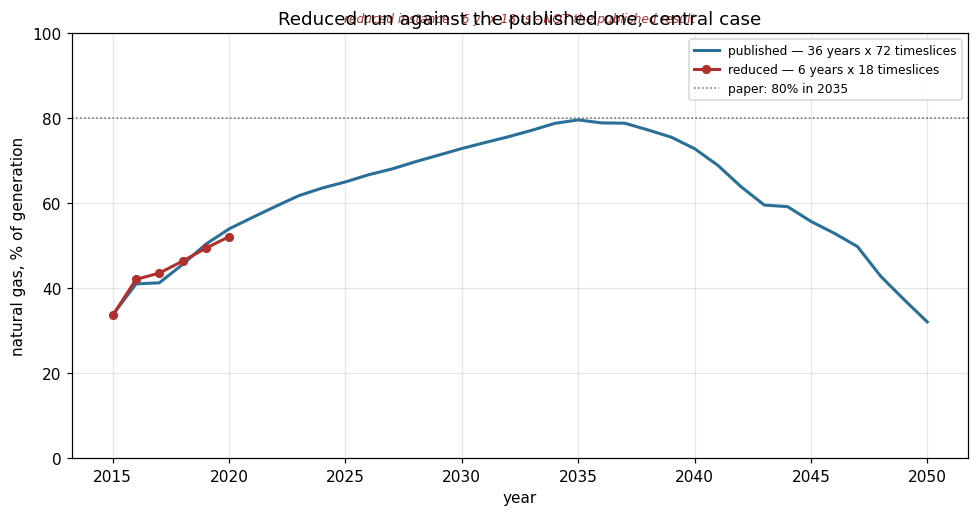

In [13]:
from sav_osemosys.figures import gas_share

fig, ax = plt.subplots(figsize=(9, 4.8))

full = gas_share(published, 3)
ax.plot([int(y) for y in full.index], full.values, lw=2, color="#2a6f97",
        label="published — 36 years x 72 timeslices")
if reduced:
    ys = sorted(reduced)
    ax.plot(ys, [reduced[y] for y in ys], lw=2, marker="o", ms=5, color="#b03030",
            label="reduced — 6 years x 18 timeslices")
ax.axhline(80, color="0.4", lw=1, ls=":", label="paper: 80% in 2035")
ax.set_xlabel("year"); ax.set_ylabel("natural gas, % of generation")
ax.set_ylim(0, 100); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Reduced run against the published one, central case")
ax.text(0.5, 1.02, "reduced instance - 6 yr x 18 ts - NOT the published result",
        transform=ax.transAxes, ha="center", va="bottom",
        fontsize=8, color="#b03030", style="italic")
plt.tight_layout(); plt.show()

## What to take away

- **The formulation is readable and runnable without GAMS.** That was the barrier; CPLEX
  was never the main one.
- **It reconciles with GAMS on all ten scenarios**, to 1e-10 on eight of them.
- **It is 12× smaller than the GAMS model** and that is not an approximation — it is
  declining to create variables that can only be zero.
- **Two solvers agree** on the reduced instance to 1e-10, one of them free.

The claim this notebook does *not* make is reproduction of the paper. That is
`00_verify.ipynb`, and it needs no solver, no licence and no Gurobi.